<a href="https://colab.research.google.com/github/samoliverramos/FIAP2026/blob/main/Praticas_Redes_Neurais/Aula04_MLP_em_Keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula 04 – Primeira Rede Neural (MLP) com Keras
## Disciplina: Redes Neurais Artificiais, Deep Learning e Algoritmos Genéticos – 1TIAPG
Prof. Samir Ramos

**Objetivos da aula:**
- Relembrar Perceptron e entender por que precisamos de várias camadas (MLP).
- Montar uma rede neural feedforward simples usando Keras (TensorFlow).
- Treinar e avaliar um modelo de classificação binária (cliente compra ou não compra).
- Fazer pequenos experimentos com número de neurônios e épocas.

**Contexto:**
Você é analista de dados em um e-commerce de São Paulo. Queremos prever se um cliente vai **comprar (1) ou não comprar (0)** com base no seu comportamento no site.

2. Imports e setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

sns.set(style="whitegrid")
print("TensorFlow:", tf.__version__)

TensorFlow: 2.19.0


3. Geração de dados sintéticos “realistas”

“Este dataset é sintético, gerado para simular um cenário realista.”

In [3]:
# Gerando um dataset sintético de classificação binária
# Cada linha = um visitante do site
# y = 1 se comprou, 0 se não comprou

X, y = make_classification(
    n_samples=2000,
    n_features=5,
    n_informative=4,
    n_redundant=0,
    n_clusters_per_class=2,
    random_state=42
)

df = pd.DataFrame(X, columns=[
    "tempo_no_site",          # em minutos
    "paginas_visitadas",      # quantidade de páginas
    "valor_medio_carrinho",   # valor médio dos produtos vistos
    "veio_de_campanha",       # 1 se clicou em campanha/ads, 0 se veio direto
    "dispositivo_mobile"      # 1 se mobile, 0 se desktop
])
df["comprou"] = y

df.head()

,tempo_no_site,paginas_visitadas,valor_medio_carrinho,veio_de_campanha,dispositivo_mobile,comprou
0,1.054100,-1.087813,1.335500,0.813045,-0.562986,0
1,-0.424794,-1.186549,-2.064998,-0.565308,-0.645506,1
2,-0.486995,-0.653427,2.318105,1.168551,0.013254,0
3,0.342168,-1.064648,1.430961,0.767402,-0.448590,0
4,0.791009,-0.050421,-2.582942,-2.298647,-0.458048,0


4. EDA mínima

In [4]:
df.describe()

,tempo_no_site,paginas_visitadas,valor_medio_carrinho,veio_de_campanha,dispositivo_mobile,comprou
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,-0.016636,-0.492117,-0.056281,-0.049817,-0.485523,0.499500
std,1.000312,1.473479,1.528581,1.437495,1.554797,0.500125
min,-3.425363,-5.166188,-5.159275,-5.332171,-6.293302,0.000000
25%,-0.693970,-1.471003,-1.084827,-1.122414,-1.489253,0.000000
50%,-0.017106,-0.614119,0.281243,-0.043721,-0.642175,0.000000
75%,0.669370,0.464806,1.083337,1.013287,0.434354,1.000000
max,3.208769,5.042266,4.435117,4.634370,4.765042,1.000000


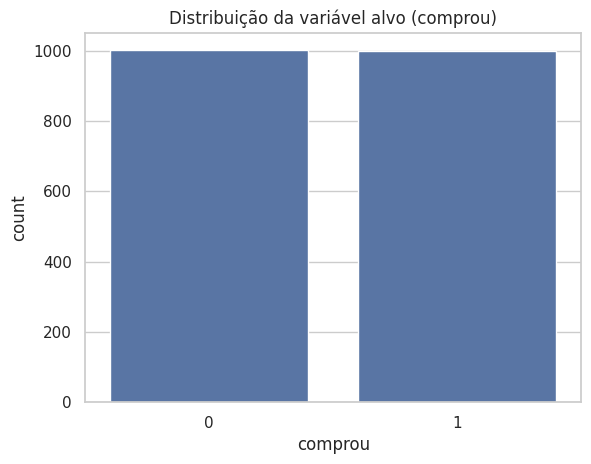

In [5]:
# Distribuição da variável alvo
sns.countplot(x="comprou", data=df)
plt.title("Distribuição da variável alvo (comprou)")
plt.show()

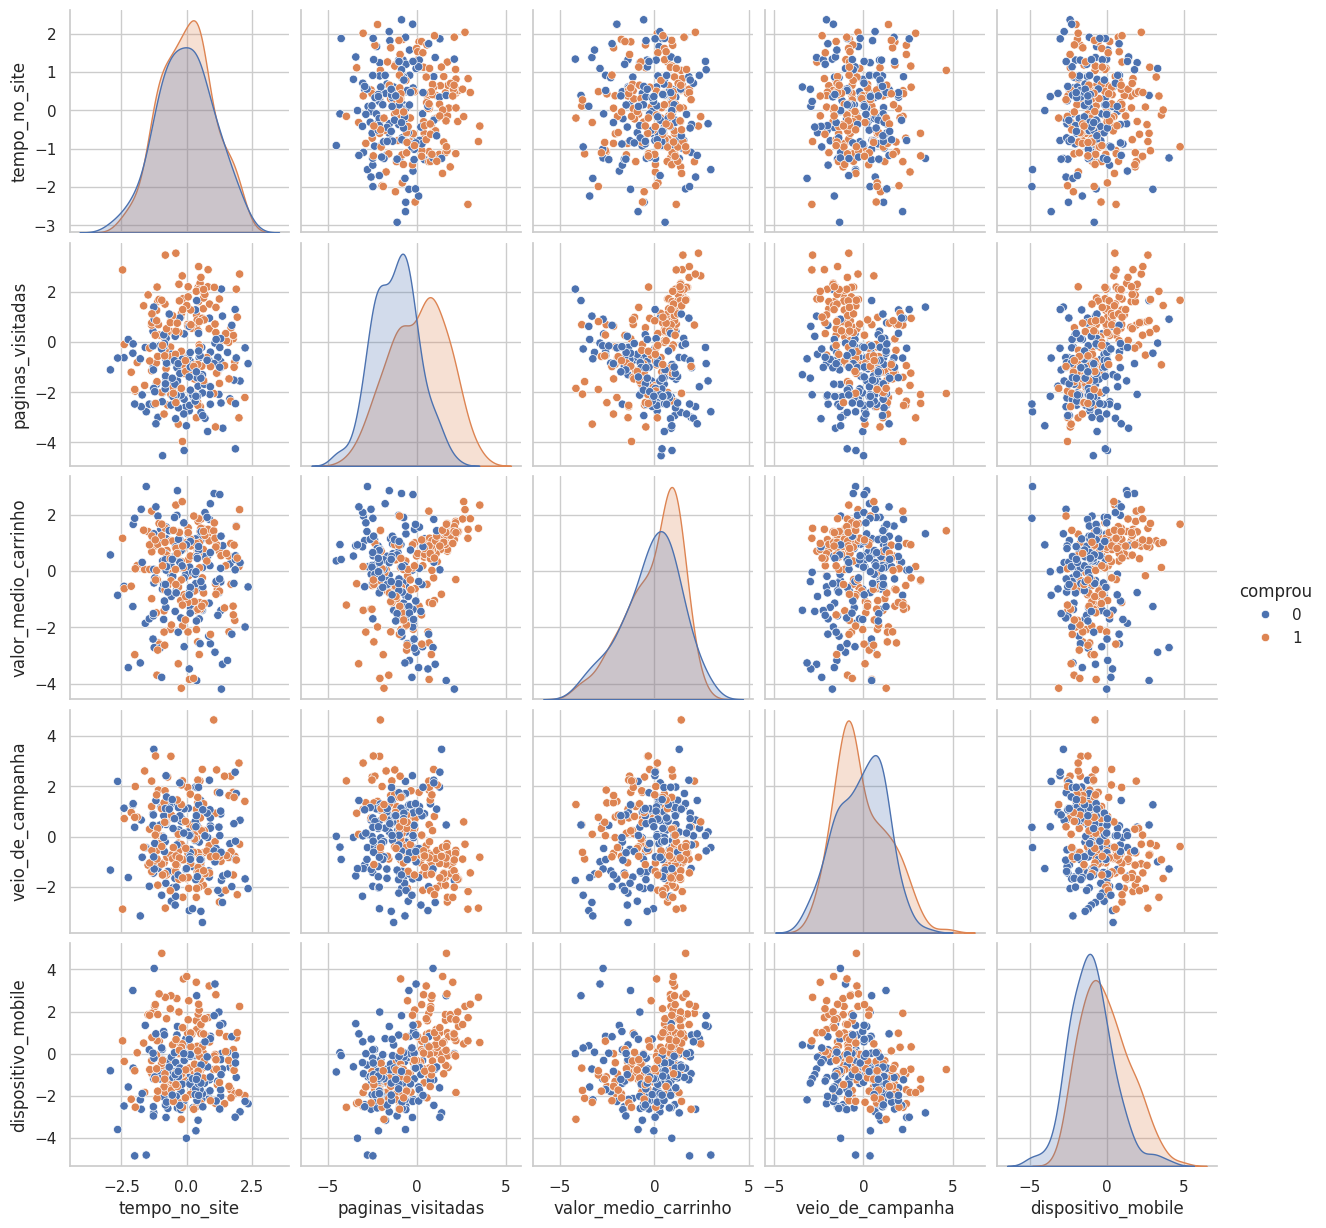

In [6]:
# Amostra para não ficar muito pesado
sns.pairplot(df.sample(300, random_state=42), hue="comprou")
plt.show()

DICA IMPORTANTE: “Antes de treinar rede neural, sempre olhar a base.”

5. Separar treino e teste + normalização

In [8]:
X = df.drop("comprou", axis=1).values
y = df["comprou"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled.shape, X_test_scaled.shape

((1600, 5), (400, 5))

DICA: “Redes neurais treinam melhor quando os dados são escalonados (média ~0, desvio ~1).”

6. Definição da MLP (modelo base)

In [9]:
# Definindo uma rede neural feedforward (MLP) simples

model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),  # 5 features
    layers.Dense(8, activation="relu"),              # camada escondida
    layers.Dense(4, activation="relu"),              # outra camada escondida
    layers.Dense(1, activation="sigmoid")            # saída binária (probabilidade)
])

model.summary()

""""
5 inputs (features)
2 camadas escondidas: 8 e 4 neurônios com ReLU
Saída: 1 neurônio com Sigmoid (probabilidade de “comprou”)
"""

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 89 (356.00 B)

 Trainable params: 89 (356.00 B)

 Non-trainable params: 0 (0.00 B)

'"\n5 inputs (features)\n2 camadas escondidas: 8 e 4 neurônios com ReLU\nSaída: 1 neurônio com Sigmoid (probabilidade de “comprou”)\n'

IMPORTANTE:

- Cada Dense é uma camada totalmente conectada (todos neurônios conectados com a camada anterior).
- relu nas camadas escondidas → boa para aprender não linearidades.
- sigmoid na saída → probabilidade de comprou = 1.

EXPLICAÇÃO DETALHADA (PARA APROFUNDAMENTO):

Esse quadro é o model.summary() da sua MLP.

1. Coluna “Layer (type)”
Mostra as camadas da rede, na ordem:

dense (Dense) → primeira camada totalmente conectada (hidden layer 1)
dense_1 (Dense) → segunda camada totalmente conectada (hidden layer 2)
dense_2 (Dense) → camada de saída
“Dense” = cada neurônio desta camada está conectado a todos os neurônios da camada anterior.

2. Coluna “Output Shape”
É o formato da saída de cada camada, para um batch qualquer:

dense (Dense) → (None, 8)
None = tamanho do batch (pode ser 32, 64, 128… variável)
8 = número de neurônios nessa camada
dense_1 (Dense) → (None, 4)
4 neurônios
dense_2 (Dense) → (None, 1)
1 neurônio (saída escalar: probabilidade de “comprou”)
Então:

Camada 1: vetor de 8 ativações por exemplo
Camada 2: vetor de 4 ativações por exemplo
Saída: 1 número por exemplo (probabilidade)

3. Coluna “Param #” – de onde vem 48, 36 e 5?
Regra geral de uma camada Dense:

Parâmetros = (número de entradas × número de neurônios) + (1 bias por neurônio)

Primeira camada (dense): 48 parâmetros
Entradas: 5 features (tempo_no_site, paginas_visitadas, valor_medio_carrinho, veio_de_campanha, dispositivo_mobile)
Neurônios: 8
Cálculo:

Pesos: 5 entradas × 8 neurônios = 40 pesos
Bias: 1 bias por neurônio → 8 biases
Total = 40 + 8 = 48
É exatamente o que aparece:

dense (Dense) │ (None, 8) │ 48

Segunda camada (dense_1): 36 parâmetros
Entradas: 8 (saída da camada anterior)
Neurônios: 4
Cálculo:

Pesos: 8 × 4 = 32
Bias: 4
Total = 32 + 4 = 36
dense_1 (Dense) │ (None, 4) │ 36

Camada de saída (dense_2): 5 parâmetros
Entradas: 4 (saída da camada anterior)
Neurônios: 1
Cálculo:

Pesos: 4 × 1 = 4
Bias: 1
Total = 4 + 1 = 5
dense_2 (Dense) │ (None, 1) │ 5

4. Total params, Trainable, Non-trainable
Total params: 48 + 36 + 5 = 89
Trainable params: 89
Todos esses 89 parâmetros (pesos + biases) serão ajustados pelo backpropagation/Adam.
Non-trainable params: 0
Não há nada “congelado” (como embeddings pré-treinadas ou camadas com pesos fixos).
Ou seja: sua MLP tem 89 “knobs” (pesos/biases) que o algoritmo de treino mexe para reduzir a função de perda.

RESUMÃO PARA GUARDAR SOBRE ESSA ETAPA

- Cada camada Dense tem um conjunto de pesos ligando cada neurônio da camada anterior a cada neurônio da camada atual + um bias por neurônio.

Fórmula: parâmetros = entradas × neurônios + neurônios

- Na primeira camada, temos 5 entradas e 8 neurônios:
5 × 8 = 40 pesos, mais 8 biases = 48 parâmetros.

É isso que o Keras está mostrando: 48 + 36 + 5 = 89 valores que serão aprendidos durante o treino.

7. Compilar o modelo

In [11]:
model.compile(
    optimizer="adam",                # variante do gradiente descendente
    loss="binary_crossentropy",      # erro para classificação binária
    metrics=["accuracy"]             # vamos acompanhar accuracy
)

COMENTÁRIO:

“Aqui o Keras está configurando como vai fazer o feedforward + backprop internamente.”

8. Treinar o modelo

In [12]:
history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,  # parte do treino vira validação
    epochs=20,
    batch_size=32,
    verbose=0              # mude para 1 se quiser ver o log em tempo real
)

9. Curvas de treinamento (loss e accuracy)

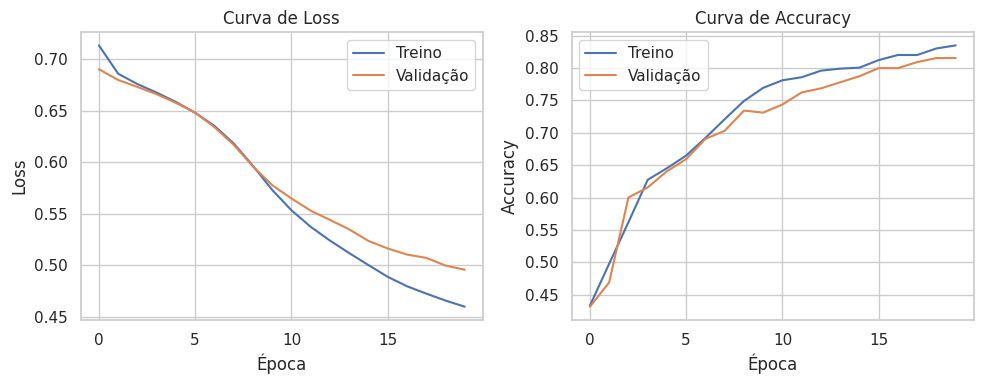

In [13]:
# Curva de Loss
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="Treino")
plt.plot(history.history["val_loss"], label="Validação")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.title("Curva de Loss")

# Curva de Accuracy
plt.subplot(1,2,2)
plt.plot(history.history["accuracy"], label="Treino")
plt.plot(history.history["val_accuracy"], label="Validação")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Curva de Accuracy")

plt.tight_layout()
plt.show()

PERGUNTAS PARA DEBATE:

- “As curvas de treino e validação estão parecidas ou se afastando?”
- “Parece que tem overfitting? Em que época ele começaria?”

In [ ]:
# PERGUNTAS PARA DEBATE SOBRE AS CURVAS

"""
1) “As curvas de treino e validação estão parecidas ou se afastando?”

   O que observar no gráfico:

   - Curvas PARECIDAS (andando “juntas”):
     Se a métrica de treino e a de validação têm valores próximos e seguem
     mais ou menos a mesma tendência (sobem ou descem juntas), isso é um
     sinal de que o modelo está conseguindo aprender o padrão dos dados
     sem “decorar demais” o conjunto de treino.

   - Curvas SE AFASTANDO:
     Quando a curva de treino continua melhorando (por exemplo, loss de treino
     diminuindo ou accuracy de treino aumentando), mas a curva de validação
     para de melhorar (fica estável) ou até piora, significa que o modelo
     está começando a se ajustar demais aos detalhes do treino e não está
     generalizando bem para novos dados.

   Na prática:
     - Pergunte-se: a linha de validação segue a de treino ou começa a abrir
       um “V” ou “gap” entre elas?
     - Esse “gap” é um primeiro sinal visual de possível overfitting.


2) “Parece que tem overfitting? Em que época ele começaria?”

   Overfitting (sobreajuste) acontece quando:
     - O modelo fica muito bom no CONJUNTO DE TREINO,
     - Mas começa a piorar no CONJUNTO DE VALIDAÇÃO.

   Como identificar no gráfico:
     - Procure o ponto (época) a partir do qual:
         * a curva de treino CONTINUA melhorando (loss desce ou accuracy sobe),
         * mas a curva de validação PARA de melhorar ou começa a piorar.
     - Esse ponto é uma boa estimativa de onde o overfitting começa.

   Exemplo de leitura:
     - Digamos que até a época 8, treino e validação melhoram juntos.
     - A partir da época 9:
         * a loss de treino continua caindo,
         * mas a loss de validação começa a subir.
     - Podemos dizer: "O overfitting parece começar por volta da época 9."

   Ideia para discutir com a turma:
     - “Se o overfitting começa na época X, faz sentido treinar até 50 épocas?”
     - “E se pararmos o treinamento próximo da melhor época de validação?”
       (isso é a intuição do ‘early stopping’).
"""

10. Avaliação no conjunto de teste

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Accuracy no teste: 0.855

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.88      0.86       200
           1       0.87      0.83      0.85       200

    accuracy                           0.85       400
   macro avg       0.86      0.85      0.85       400
weighted avg       0.86      0.85      0.85       400



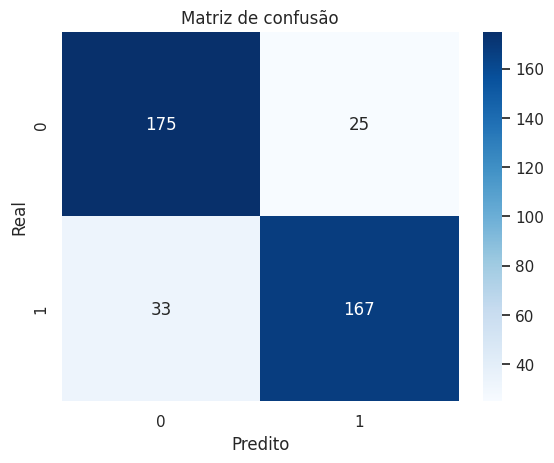

In [14]:
# Predição no conjunto de teste
y_pred_proba = model.predict(X_test_scaled).ravel()
y_pred = (y_pred_proba >= 0.5).astype(int)

print("Accuracy no teste:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de confusão")
plt.show()

Desafios guiados

### Desafio 1 – Aumente a capacidade da rede

Tarefa:
- Aumente o número de neurônios e/ou o número de camadas escondidas.
- Exemplo: 16 neurônios na primeira camada, 8 na segunda, 4 na terceira.
- Re-treine o modelo por 20 épocas e compare:
  - Accuracy no treino e validação.
  - Accuracy no teste.
  - Curvas de loss e accuracy.

Perguntas:
- O modelo melhorou?
- Apareceu overfitting?

Código-esqueleto para mexer e reaproveitar as funções de plot + avaliação.

In [ ]:
model2 = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(16, activation="relu"),
    layers.Dense(8, activation="relu"),
    layers.Dense(4, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model2.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

history2 = model2.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    verbose=0
)

Desafio 2 – Mudar o número de epochs

### Desafio 2 – Menos ou mais épocas?

Tarefa:
- Treine a mesma arquitetura com:
  - 5 épocas
  - 50 épocas
- Compare:
  - Tempo de treino
  - Curvas de treino/validação
  - Accuracy no teste

Perguntas:
- Em 5 épocas, o modelo já aprendeu o suficiente?
- Em 50 épocas, acontece overfitting?

Desafio 3 – Trocar função de ativação

### Desafio 3 – E se trocarmos a função de ativação?

Tarefa:
- Troque `activation="relu"` por `activation="tanh"` nas camadas escondidas.
- Mantenha o resto igual.
- Compare desempenho com a versão original.

Perguntas:
- Qual ativação funcionou melhor?
- Você observa diferenças nas curvas de loss/accuracy?

RESUMO DA AULA:
- Hoje a gente deu o salto de 1 neurônio → várias camadas.
- Vocês viram feedforward e backprop acontecendo via Keras, sem precisar codificar cálculo de gradiente.

Pergunta:
- Em que casos um modelo mais simples (como regressão logística ou árvore de decisão) ainda faz sentido em vez de rede neural?

TAREFA COMPLEMENTAR (opcional):
- Salvar o notebook, alterar a proporção de test_size (0.1, 0.3) e observar o impacto.
- Adicionar uma nova feature sintética (por exemplo, tempo_no_site * paginas_visitadas) e testar.